In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Mount Google Drive



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

dataset_path = '/content/drive/My Drive/dataset'
print(f"Listing contents of: {dataset_path}")



Listing contents of: /content/drive/My Drive/dataset


In [ ]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # this mean and std is chosen bcz this is of imagenet, as we do TL later, this will help
])

In [ ]:
dataset = datasets.ImageFolder(root = dataset_path, transform=image_transforms)
len(dataset)

2300

In [ ]:
class_names = dataset.classes

In [ ]:
num_classes = len(dataset.classes)
num_classes

6

In [ ]:
train_size = int(0.75*len(dataset))
val_size = len(dataset)-train_size

In [ ]:
train_size, val_size

(1725, 575)

In [ ]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [ ]:
for images,labels in train_loader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([32, 3, 224, 224])
torch.Size([32])


32 = size of batch -----
3 = 3 channel (rgb) -----
224,224 = size of image

In [ ]:
images[0].shape

torch.Size([3, 224, 224])

In [ ]:
labels[4]

tensor(1)

In [ ]:
images[0].permute(1,2,0).shape #this is done to make [3,224,224] to [224,224,3] coz plt.imshow explects in this order

torch.Size([224, 224, 3])

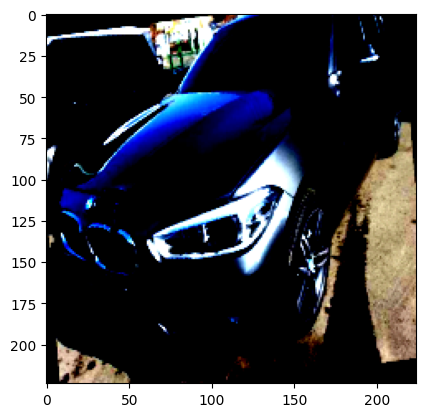

In [ ]:
plt.imshow(images[4].permute(1,2,0))

## Model 1 : CNN

In [ ]:
class CarClassifierCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.network = nn.Sequential(
        nn.Conv2d(in_channels=3 , out_channels=16,kernel_size =3, stride= 1, padding=1), # in=(3,224,224) , out=(16,224,224) , 224 itself as padding is set to 1orsame
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding = 0), # in=(16,224,224) , out=(16,112,112)

        nn.Conv2d(in_channels=16 , out_channels=32, kernel_size =3, stride= 1, padding=1), # in=(16,112,112) , out=(32,112,112)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding = 0), # in=(32,112,112) , out=(32,56,56)

        nn.Conv2d(in_channels=32 , out_channels=64,kernel_size =3, stride= 1, padding=1), # in=(32,56,56) , out=(64,56,56)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding = 0), # in=(64,56,56) , out=(64,28,28)
        nn.Flatten(),

        nn.Linear(64*28*28, 512),
        nn.ReLU(),
        nn.Linear(512, num_classes)
    )
  def forward(self,x):
    x = self.network(x)
    return x

In [ ]:
model = CarClassifierCNN(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
def train_model(model, criterion, optimizer, epochs=5):
  start = time.time()
  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_num, (images, labels) in enumerate(train_loader):
      images, labels = images.to(device), labels.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      # 1.Forward pass
      output = model(images)
      loss = criterion(output, labels)

      # 2.Backward pass
      loss.backward()
      optimizer.step()

      if(batch_num+1) % 10 ==0:
        print(f'Epoch: {epoch+1}, Batch: {batch_num+1}, Loss: {loss.item():.2f}')

      running_loss += loss.item()*images.size(0)

    epoch_loss = running_loss/len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")
    # Validation
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

      print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds")

  return all_labels, all_predictions

In [ ]:
train_model(model, criterion, optimizer, epochs=5)

Epoch: 1, Batch: 10, Loss: 1.87
Epoch: 1, Batch: 20, Loss: 1.72
Epoch: 1, Batch: 30, Loss: 1.68
Epoch: 1, Batch: 40, Loss: 1.62
Epoch: 1, Batch: 50, Loss: 1.59
Epoch [1/5], Avg Loss: 1.9696
*** Validation Accuracy: 37.39% ***
Execution time: 657.8181071281433 seconds
Epoch: 2, Batch: 10, Loss: 1.50
Epoch: 2, Batch: 20, Loss: 1.39
Epoch: 2, Batch: 30, Loss: 1.56
Epoch: 2, Batch: 40, Loss: 1.05
Epoch: 2, Batch: 50, Loss: 1.03
Epoch [2/5], Avg Loss: 1.3430
*** Validation Accuracy: 47.83% ***
Execution time: 740.291348695755 seconds
Epoch: 3, Batch: 10, Loss: 1.14
Epoch: 3, Batch: 20, Loss: 0.98
Epoch: 3, Batch: 30, Loss: 0.89
Epoch: 3, Batch: 40, Loss: 1.03
Epoch: 3, Batch: 50, Loss: 1.36
Epoch [3/5], Avg Loss: 1.1165
*** Validation Accuracy: 50.96% ***
Execution time: 821.1174278259277 seconds
Epoch: 4, Batch: 10, Loss: 0.96
Epoch: 4, Batch: 20, Loss: 1.16
Epoch: 4, Batch: 30, Loss: 0.90
Epoch: 4, Batch: 40, Loss: 0.93
Epoch: 4, Batch: 50, Loss: 0.81
Epoch [4/5], Avg Loss: 1.0162
*** Val

loss is decreasing but validation accuracy is not incrasing, means overfitting

lets try regularization to overcome overfitting

# Model 2 : CNN with Regularization

In [ ]:
class CarClassifierCNNwithRegularization(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.network = nn.Sequential(
        nn.Conv2d(in_channels=3 , out_channels=16,kernel_size =3, stride= 1, padding=1), # in=(3,224,224) , out=(16,224,224) , 224 itself as padding is set to 1orsame
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding = 0), # in=(16,224,224) , out=(16,112,112)

        nn.Conv2d(in_channels=16 , out_channels=32, kernel_size =3, stride= 1, padding=1), # in=(16,112,112) , out=(32,112,112)
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding = 0), # in=(32,112,112) , out=(32,56,56)

        nn.Conv2d(in_channels=32 , out_channels=64,kernel_size =3, stride= 1, padding=1), # in=(32,56,56) , out=(64,56,56)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2, padding = 0), # in=(64,56,56) , out=(64,28,28)
        nn.Flatten(),

        nn.Linear(64*28*28, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
  def forward(self,x):
    x = self.network(x)
    return x

In [ ]:
model = CarClassifierCNNwithRegularization(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # L2 Regularization


Changes are ====== 1. Batch Normalization ----
             2. Dropout Layer ----
             3. weight Decay i.e L2 Regularization




In [ ]:
train_model(model, criterion, optimizer, epochs=10)


Epoch: 1, Batch: 10, Loss: 10.49
Epoch: 1, Batch: 20, Loss: 4.74
Epoch: 1, Batch: 30, Loss: 2.23
Epoch: 1, Batch: 40, Loss: 1.69
Epoch: 1, Batch: 50, Loss: 1.34
Epoch [1/10], Avg Loss: 7.6372
*** Validation Accuracy: 44.52% ***
Execution time: 80.6557023525238 seconds
Epoch: 2, Batch: 10, Loss: 1.65
Epoch: 2, Batch: 20, Loss: 1.23
Epoch: 2, Batch: 30, Loss: 1.34
Epoch: 2, Batch: 40, Loss: 1.28
Epoch: 2, Batch: 50, Loss: 1.28
Epoch [2/10], Avg Loss: 1.3875
*** Validation Accuracy: 48.87% ***
Execution time: 162.51903367042542 seconds
Epoch: 3, Batch: 10, Loss: 1.19
Epoch: 3, Batch: 20, Loss: 1.13
Epoch: 3, Batch: 30, Loss: 1.22
Epoch: 3, Batch: 40, Loss: 1.47
Epoch: 3, Batch: 50, Loss: 1.14
Epoch [3/10], Avg Loss: 1.2727
*** Validation Accuracy: 51.30% ***
Execution time: 244.8182556629181 seconds
Epoch: 4, Batch: 10, Loss: 1.02
Epoch: 4, Batch: 20, Loss: 1.04
Epoch: 4, Batch: 30, Loss: 1.02
Epoch: 4, Batch: 40, Loss: 1.19
Epoch: 4, Batch: 50, Loss: 1.11
Epoch [4/10], Avg Loss: 1.1741
*

# Model 3 : Transfer Learning with EfficientNet

In [ ]:
#below code is just to check input feature to the classifier layer in efficient net, the model assigned below notthing to do with traiing, we assign model later after building network
model = models.efficientnet_b0(weights = 'DEFAULT')
model.classifier[1].in_features

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 110MB/s] 


1280

In [ ]:
#load pretrained Efficietnet model
class CarClassifierEfficicentNet(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.model = models.efficientnet_b0(weights='DEFAULT')

    # Freeze all layers except final fc layer
    for param in self.model.parameters():
      param.requires_grad = False

    in_features = self.model.classifier[1].in_features

    # Replace final fc layer
    self.model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
  def forward(self, x):
    x = self.model(x)
    return x




In [ ]:
model = CarClassifierEfficicentNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad,model.parameters()), lr=0.001)


In [ ]:
train_model(model, criterion, optimizer, epochs = 5)

Epoch: 1, Batch: 10, Loss: 1.50
Epoch: 1, Batch: 20, Loss: 1.67
Epoch: 1, Batch: 30, Loss: 1.45
Epoch: 1, Batch: 40, Loss: 1.40
Epoch: 1, Batch: 50, Loss: 1.41
Epoch [1/5], Avg Loss: 1.4894
*** Validation Accuracy: 54.78% ***
Execution time: 85.12658190727234 seconds
Epoch: 2, Batch: 10, Loss: 1.20
Epoch: 2, Batch: 20, Loss: 1.00
Epoch: 2, Batch: 30, Loss: 1.08
Epoch: 2, Batch: 40, Loss: 1.14
Epoch: 2, Batch: 50, Loss: 1.09
Epoch [2/5], Avg Loss: 1.1388
*** Validation Accuracy: 61.39% ***
Execution time: 167.13587403297424 seconds
Epoch: 3, Batch: 10, Loss: 1.13
Epoch: 3, Batch: 20, Loss: 0.91
Epoch: 3, Batch: 30, Loss: 0.97
Epoch: 3, Batch: 40, Loss: 1.18
Epoch: 3, Batch: 50, Loss: 1.18
Epoch [3/5], Avg Loss: 1.0097
*** Validation Accuracy: 58.09% ***
Execution time: 248.72247838974 seconds
Epoch: 4, Batch: 10, Loss: 1.07
Epoch: 4, Batch: 20, Loss: 0.86
Epoch: 4, Batch: 30, Loss: 0.98
Epoch: 4, Batch: 40, Loss: 1.15
Epoch: 4, Batch: 50, Loss: 1.14
Epoch [4/5], Avg Loss: 0.9542
*** Val

# Model 4 : Transfer Learning with ResNet

In [ ]:
#load pretrained Reset model
class CarClassifierResNet(nn.Module):
  def __init__(self, num_classes, dropout_rate=0.5):
    super().__init__()
    self.model = models.resnet50(weights='DEFAULT')

    # Freeze all layers except final fc layer
    for param in self.model.parameters():
      param.requires_grad = False

    in_features = self.model.fc.in_features

    # Unfreeze Layer-4 and Replace final fc layer
    for param in self.model.layer4.parameters():
      param.requires_grad = True

    self.model.fc = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, num_classes)
    )
  def forward(self, x):
    x = self.model(x)
    return x




In [ ]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad,model.parameters()), lr=0.001)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


In [ ]:
labels, predictions = train_model(model, criterion, optimizer, epochs = 5)

KeyboardInterrupt: 

In other notebooks hyperparameter tuning came to know that best param for resnet are 1. Dropout rate = 0.2, 2. Lr = 0.005

In [ ]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad,model.parameters()), lr=0.005)




In [ ]:
labels, predictions = train_model(model, criterion, optimizer, epochs = 10)

Epoch: 1, Batch: 10, Loss: 0.87
Epoch: 1, Batch: 20, Loss: 0.56
Epoch: 1, Batch: 30, Loss: 0.94
Epoch: 1, Batch: 40, Loss: 0.52
Epoch: 1, Batch: 50, Loss: 0.73
Epoch [1/10], Avg Loss: 0.8791
*** Validation Accuracy: 64.52% ***
Execution time: 744.7247757911682 seconds
Epoch: 2, Batch: 10, Loss: 0.35
Epoch: 2, Batch: 20, Loss: 0.62
Epoch: 2, Batch: 30, Loss: 0.52
Epoch: 2, Batch: 40, Loss: 0.40
Epoch: 2, Batch: 50, Loss: 0.51
Epoch [2/10], Avg Loss: 0.5073
*** Validation Accuracy: 72.35% ***
Execution time: 831.1575772762299 seconds
Epoch: 3, Batch: 10, Loss: 0.35
Epoch: 3, Batch: 20, Loss: 0.22
Epoch: 3, Batch: 30, Loss: 0.57
Epoch: 3, Batch: 40, Loss: 0.28
Epoch: 3, Batch: 50, Loss: 0.42
Epoch [3/10], Avg Loss: 0.3479
*** Validation Accuracy: 74.43% ***
Execution time: 917.0543661117554 seconds
Epoch: 4, Batch: 10, Loss: 0.34
Epoch: 4, Batch: 20, Loss: 0.20
Epoch: 4, Batch: 30, Loss: 0.20
Epoch: 4, Batch: 40, Loss: 0.62
Epoch: 4, Batch: 50, Loss: 0.31
Epoch [4/10], Avg Loss: 0.2909
**

Model Evaluation

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       124
           1       0.83      0.70      0.76       122
           2       0.89      0.89      0.89       124
           3       0.71      0.85      0.78        59
           4       0.75      0.64      0.69        74
           5       0.78      0.79      0.79        72

    accuracy                           0.80       575
   macro avg       0.79      0.79      0.79       575
weighted avg       0.80      0.80      0.80       575



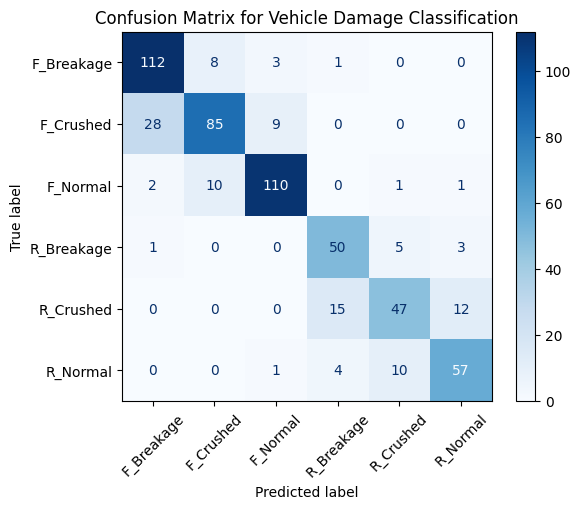

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_mtrx = confusion_matrix(labels, predictions, labels = np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtrx, display_labels= class_names)
disp.plot(cmap=plt.cm.Blues,xticks_rotation = 45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()